<a href="https://colab.research.google.com/github/WelfLowe/ML4non-programmers/blob/main/AI_in_social_science.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# AI WORKSHOP NOTEBOOK





## SETUP



In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression

## TRACK A — QUALITATIVE CODING

Denna del demonstrerar användningen av en stor språkmodell (LLM) för kvalitativ kodning.
Den tar en lista med era forskningsfrågor och datakällor, tillsammans med fördefinierade kategorier, och använder Gemini-API:et för att tilldela varje post en kategori samt ge en motivering.

Detta illustrerar hur LLM:er kan automatisera eller stödja kategorisering av textdata baserat på givna kriterier.

### LLM SETUP (GEMINI API)

**[Advanced!!!]** Set up your Google API Key from Colab secrets.
1. Create a key at https://aistudio.google.com/app/api-keys
2. Click the '🔑' icon in the left panel of Colab.
3. Add a new secret with the name 'GOOGLE_API_KEY' and paste your API key as the value.
4. Make sure to enable 'Notebook access' for this secret.

**[Alternative!!!]** Accept the answer and go to the next field.

In [32]:
import google.generativeai as genai
from google.colab import userdata

GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')
genai.configure(api_key=GOOGLE_API_KEY)

def llm_call(prompt):
    model = genai.GenerativeModel('gemini-2.5-pro') # Using 'gemini-2.5-pro' model
    response = model.generate_content(prompt)
    return response.text


texts_sv = [
    "Fråga: Samverkan inom brottsförebyggande arbete - hur görs den? | Data: Transkribering",
    "Fråga: Hur konstrueras maskulinitet och sexualitet i en online dopinggemenskap och i relation till dopingpraktikens kroppsliga effekter? | Data: Data från dopingforum såsom Flashback eller Thinksteroids.com",
    "Fråga: Ge förslag till utkast till en artikel i en vetenskaplig tidskrift. | Data: Delar ur en monografiavhandling",
    "Fråga: Hur skiljer sig stavningsutveckling hos elever som deltar i evidensbaserad läsundervisning från elever i 'teaching as usual'? | Data: Kvantitativ data från LegiLexis screening-test",
    "Fråga: Metaanalyser med omfattande data i open source som kan korsas longitudinellt och geografiskt med demografisk data. | Data: Open source-data om förmåner/bidrag kopplat till demografi",
    "Fråga: Hur positionerar sig Youtubekanalen Riks gentemot mainstreammedia? | Data: Youtube-videor analyserade med teoretisk analysram",
    "Fråga: Vilka möjligheter respektive utmaningar framträder kring ungdomars utbildning och arbetsmarknadens kompetensbehov? | Data: Styrgruppsprotokoll och regionala analyser",
    "Fråga: Identifiera möjligheter och utmaningar för tränare inom internationella SDP-insatser. | Data: Peer review-artiklar",
    "Fråga: Går det att använda AI för textanalys av fokusgruppintervjuer och är det tillförlitligt? | Data: Transkriberade fokusgruppintervjuer",
    "Fråga: Hur ser den inrikes omflyttningen av utrikes födda ut 2015–2025? | Data: SCB-data + intervjuer med migranter",
    "Fråga: Hur beskrivs barns omsorgsarbete i barnavårdsutredningar? | Data: Socialtjänstens utredningsdokument",
    "Fråga: Hur förändras kommuners tolkning av skolplaceringsregler för elever med NPF över tid? | Data: Policy och åtgärdsprogram",
    "Fråga: Omfattningen av centraliseringen av svensk förlossningsvård? | Data: Exempelvis Socialstyrelsens databas över födslar i Sverige",
    "Fråga: Hur upplever kemistudenter representationer av molekylorbitalteori? | Data: Stimulated recall-intervjuer + föreläsningsinspelningar",
    "Fråga: Hur kan AI användas i översiktlig analys av kvantdata? Ger olika modeller olika resultat? | Data: Kvantitativa dataset med variabler X och Y",
    "Fråga: Hur har synen på barnmisshandel förändrats 1950–2025 i Sverige? | Data: Dagstidningar och facktidskrifter",
    "Fråga: Hur upplever anhöriga till personer med hjärtsvikt användningen av ett internetbaserat stödprogram som riktar sig till målgruppen? | Data: Datan består av intervjuer med anhöriga (användare) som loggat in på stödprogrammet minst en gång i veckan under interventionen.",
    "Fråga: Hur kan AI användas för att identifiera och analysera olika former av socialt stöd hos flickor som idrottar under puberteten? | Data: Kvalitativt intervjumaterial från flickor i puberteten som deltar i organiserad idrott, med fokus på upplevelser av socialt stöd från tränare, lagkompisar och familj.",
    "Fråga: Hur kan man identifiera relevant tidigare forskning inom mitt forskningsområde om solidaritet, civilt motstånd, migration och asyl? | Data: publicerad forskningslitteratur, såsom vetenskapliga artiklar, böcker och rapporter inom mitt forskningsområde",
    "Fråga: Hur kan man hitta strukturer i domar för hur tilltalade försvarar sig mot tex anklagelser om våldtäkt? | Data: Den tilltalades försvar; invändningar, nekanden, vilka omständigheter som lyfts och som utelämnas.",
]
kategorier_sv = [
    "Tydlig och direkt operationaliserbar",
    "Relativt tydlig men kräver precisering",
    "Otydlig eller för bred",
    "Fokuserar på AI-metod snarare än forskningsfråga",
    "Ej lämplig för AI utan omformulering"
]

# LLM coding example (now using Gemini API)
prompt = f"""
Koda följande AI fråggor och datakällor i kategorier:
{kategorier_sv}

Returnera resultatet som en parsbar JSON-array av objekt. Varje objekt ska ha följande nycklar: 'Fråga', 'Data', 'assigned Kategori', och 'Motivering'.

Texter:
{texts_sv}
"""
print("\nLLM-based coding results (using Gemini API):")

try:
    print(llm_call(prompt))
except Exception as e:
    # Check available models if generate_content failed
    print(f"Error during LLM call: {e}")
    print("Listing available models to diagnose the issue:")
    for m in genai.list_models():
        if 'generateContent' in m.supported_generation_methods:
            print(m.name)



LLM-based coding results (using Gemini API):
```json
[
  {
    "Fråga": "Samverkan inom brottsförebyggande arbete - hur görs den?",
    "Data": "Transkribering",
    "assigned Kategori": "Otydlig eller för bred",
    "Motivering": "Frågan 'hur görs den?' är för bred och odefinierad för en AI-uppgift. Den behöver specificeras, till exempel genom att fråga om specifika teman, aktörer eller processer som kan identifieras i textdata för att bli operationaliserbar."
  },
  {
    "Fråga": "Hur konstrueras maskulinitet och sexualitet i en online dopinggemenskap och i relation till dopingpraktikens kroppsliga effekter?",
    "Data": "Data från dopingforum såsom Flashback eller Thinksteroids.com",
    "assigned Kategori": "Relativt tydlig men kräver precisering",
    "Motivering": "Frågan är en klassisk forskningsfråga som kräver djup tolkning. AI kan användas för att identifiera teman och mönster, men begreppet 'konstrueras' kräver att man preciserar exakt vilka textuella markörer och relatio

In [33]:
svar = """
json
[
  {
    "Fråga": "Samverkan inom brottsförebyggande arbete - hur görs den?",
    "Data": "Transkribering",
    "assigned Kategori": "Otydlig eller för bred",
    "Motivering": "Frågan 'hur görs den?' är mycket bred och odefinierad. För att kunna operationaliseras för en AI-analys behöver den specificeras, t.ex. 'Vilka teman är vanligast i diskussioner om lyckad samverkan?' eller 'Vilka aktörer nämns oftast?'."
  },
  {
    "Fråga": "Hur konstrueras maskulinitet och sexualitet i en online dopinggemenskap och i relation till dopingpraktikens kroppsliga effekter?",
    "Data": "Data från dopingforum såsom Flashback eller Thinksteroids.com",
    "assigned Kategori": "Relativt tydlig men kräver precisering",
    "Motivering": "Frågan är en kvalitativ forskningsfråga som är lämplig för textanalys. En AI kan identifiera teman och mönster. Dock är begreppet 'konstrueras' komplext och skulle kräva en noggrann precisering av vilka språkliga markörer eller teman som AI:n ska leta efter för att analysen ska bli meningsfull."
  },
  {
    "Fråga": "Ge förslag till utkast till en artikel i en vetenskaplig tidskrift.",
    "Data": "Delar ur en monografiavhandling",
    "assigned Kategori": "Tydlig och direkt operationaliserbar",
    "Motivering": "Detta är en tydlig uppgift för en generativ AI (LLM). AI:n kan instrueras att sammanfatta, omstrukturera och formulera om text från en monografi till ett utkast anpassat för en vetenskaplig artikel."
  },
  {
    "Fråga": "Hur skiljer sig stavningsutveckling hos elever som deltar i evidensbaserad läsundervisning från elever i 'teaching as usual'?",
    "Data": "Kvantitativ data från LegiLexis screening-test",
    "assigned Kategori": "Tydlig och direkt operationaliserbar",
    "Motivering": "Frågan är en väldefinierad kvantitativ forskningsfråga. Med strukturerad data från screening-test kan en AI användas för att utföra statistisk analys, jämföra grupperna och visualisera utvecklingen över tid."
  },
  {
    "Fråga": "Metaanalyser med omfattande data i open source som kan korsas longitudinellt och geografiskt med demografisk data.",
    "Data": "Open source-data om förmåner/bidrag kopplat till demografi",
    "assigned Kategori": "Otydlig eller för bred",
    "Motivering": "Detta är inte en formulerad forskningsfråga, utan snarare en beskrivning av en metod eller ett projektområde. För att vara operationaliserbar behöver en specifik fråga ställas, t.ex. 'Hur har sambandet mellan [specifik förmån] och [specifik demografisk variabel] förändrats över tid i olika svenska kommuner?'."
  },
  {
    "Fråga": "Hur positionerar sig Youtubekanalen Riks gentemot mainstreammedia?",
    "Data": "Youtube-videor analyserade med teoretisk analysram",
    "assigned Kategori": "Relativt tydlig men kräver precisering",
    "Motivering": "Frågan är tydlig, men 'positionerar sig' är ett brett begrepp. För att en AI ska kunna analysera detta effektivt behöver man precisera vad man letar efter: t.ex. sentiment, specifika ämnen som diskuteras i relation till mainstreammedia, eller användningen av vissa retoriska grepp. Den teoretiska ramen kan hjälpa till med denna precisering."
  },
  {
    "Fråga": "Vilka möjligheter respektive utmaningar framträder kring ungdomars utbildning och arbetsmarknadens kompetensbehov?",
    "Data": "Styrgruppsprotokoll och regionala analyser",
    "assigned Kategori": "Otydlig eller för bred",
    "Motivering": "Frågan är mycket bred och täcker ett stort område. Begreppen 'möjligheter' och 'utmaningar' är odefinierade. För att AI ska kunna ge meningsfulla svar behöver frågan avgränsas, t.ex. till en specifik bransch, region eller typ av kompetens."
  },
  {
    "Fråga": "Identifiera möjligheter och utmaningar för tränare inom internationella SDP-insatser.",
    "Data": "Peer review-artiklar",
    "assigned Kategori": "Tydlig och direkt operationaliserbar",
    "Motivering": "Detta är en tydlig uppgift som lämpar sig väl för AI-assisterad litteraturgenomgång. En AI kan tränas att systematiskt söka igenom en stor mängd artiklar för att extrahera och kategorisera teman relaterade till 'möjligheter' och 'utmaningar'."
  },
  {
    "Fråga": "Går det att använda AI för textanalys av fokusgruppintervjuer och är det tillförlitligt?",
    "Data": "Transkriberade fokusgruppintervjuer",
    "assigned Kategori": "Fokuserar på AI-metod snarare än forskningsfråga",
    "Motivering": "Frågan handlar inte om att analysera innehållet i intervjuerna för att besvara en forskningsfråga om ett visst ämne, utan fokuserar istället på att utvärdera AI-metodens prestanda och tillförlitlighet för en specifik typ av data."
  },
  {
    "Fråga": "Hur ser den inrikes omflyttningen av utrikes födda ut 2015–2025?",
    "Data": "SCB-data + intervjuer med migranter",
    "assigned Kategori": "Relativt tydlig men kräver precisering",
    "Motivering": "Den kvantitativa delen av frågan ('hur ser omflyttningen ut?') är tydlig och kan analyseras med AI från SCB-data. Däremot krävs precisering för hur den kvalitativa datan (intervjuer) ska integreras för att besvara frågan, eller om frågan behöver kompletteras för att även täcka 'varför'-aspekten."
  },
  {
    "Fråga": "Hur beskrivs barns omsorgsarbete i barnavårdsutredningar?",
    "Data": "Socialtjänstens utredningsdokument",
    "assigned Kategori": "Tydlig och direkt operationaliserbar",
    "Motivering": "Frågan är specifik och datakällan är tydligt definierad. En AI kan användas för att systematiskt gå igenom en stor mängd textdokument, identifiera relevanta passager där barns omsorgsarbete beskrivs och sedan genomföra en tematisk analys eller sentimentanalys av dessa beskrivningar."
  },
  {
    "Fråga": "Hur förändras kommuners tolkning av skolplaceringsregler för elever med NPF över tid?",
    "Data": "Policy och åtgärdsprogram",
    "assigned Kategori": "Relativt tydlig men kräver precisering",
    "Motivering": "Frågan är bra, men begreppet 'tolkning' behöver operationaliseras. Man måste definiera vilka specifika förändringar i språkbruk, policyformuleringar eller åtgärder i dokumenten som ska räknas som en förändrad tolkning för att AI-analysen ska kunna genomföras på ett systematiskt sätt."
  },
  {
    "Fråga": "Omfattningen av centraliseringen av svensk förlossningsvård?",
    "Data": "Exempelvis Socialstyrelsens databas över födslar i Sverige",
    "assigned Kategori": "Relativt tydlig men kräver precisering",
    "Motivering": "Frågan är formulerad som ett ämne snarare än en fullständig fråga. Den behöver omformuleras (t.ex. 'Hur har antalet förlossningskliniker och deras geografiska spridning förändrats över tid?') och man behöver definiera exakt vilka mått på 'centralisering' som ska analyseras från databasen."
  },
  {
    "Fråga": "Hur upplever kemistudenter representationer av molekylorbitalteori?",
    "Data": "Stimulated recall-intervjuer + föreläsningsinspelningar",
    "assigned Kategori": "Ej lämplig för AI utan omformulering",
    "Motivering": "Frågan fokuserar på subjektiva 'upplevelser', ett komplext fenomen som är svårt för en AI att analysera meningsfullt. AI kan hjälpa till med att identifiera teman i intervjuerna, men för att verkligen besvara frågan om 'upplevelse' krävs en djupgående kvalitativ tolkning av en mänsklig forskare. Frågan skulle behöva omformuleras till att fokusera på mer observerbara språkliga mönster."
  },
  {
    "Fråga": "Hur kan AI användas i översiktlig analys av kvantdata? Ger olika modeller olika resultat?",
    "Data": "Kvantitativa dataset med variabler X och Y",
    "assigned Kategori": "Fokuserar på AI-metod snarare än forskningsfråga",
    "Motivering": "Frågan handlar om att undersöka och jämföra AI-modellers kapacitet och resultat vid dataanalys, snarare än att använda AI för att besvara en specifik forskningsfråga om sambandet mellan X och Y."
  },
  {
    "Fråga": "Hur har synen på barnmisshandel förändrats 1950–2025 i Sverige?",
    "Data": "Dagstidningar och facktidskrifter",
    "assigned Kategori": "Tydlig och direkt operationaliserbar",
    "Motivering": "Detta är en klassisk fråga för diakronisk textanalys. Med en stor digitaliserad textkorpus kan AI-verktyg effektivt analysera förändringar över tid i språkbruk, teman och sentiment kring ämnet barnmisshandel."
  },
  {
    "Fråga": "Hur upplever anhöriga till personer med hjärtsvikt användningen av ett internetbaserat stödprogram som riktar sig till målgruppen?",
    "Data": "Datan består av intervjuer med anhöriga (användare) som loggat in på stödprogrammet minst en gång i veckan under interventionen.",
    "assigned Kategori": "Relativt tydlig men kräver precisering",
    "Motivering": "I likhet med andra frågor om 'upplevelser' är detta svårt att fånga fullt ut med AI. Frågan kan dock operationaliseras genom att preciseras till mer konkreta delar av upplevelsen, t.ex. 'Vilka positiva och negativa aspekter av stödprogrammet nämns i intervjuerna?' eller 'Vilka teman är vanligast när användbarheten diskuteras?'."
  },
  {
    "Fråga": "Hur kan AI användas för att identifiera och analysera olika former av socialt stöd hos flickor som idrottar under puberteten?",
    "Data": "Kvalitativt intervjumaterial från flickor i puberteten som deltar i organiserad idrott, med fokus på upplevelser av socialt stöd från tränare, lagkompisar och familj.",
    "assigned Kategori": "Fokuserar på AI-metod snarare än forskningsfråga",
    "Motivering": "Frågan är formulerad som en undersökning av AI:s potential och metod ('Hur kan AI användas för att...') snarare än en direkt forskningsfråga om socialt stöd. En forskningsfråga skulle vara 'Vilka former av socialt stöd beskriver flickor...'."
  },
  {
    "Fråga": "Hur kan man identifiera relevant tidigare forskning inom mitt forskningsområde om solidaritet, civilt motstånd, migration och asyl?",
    "Data": "publicerad forskningslitteratur, såsom vetenskapliga artiklar, böcker och rapporter inom mitt forskningsområde",
    "assigned Kategori": "Tydlig och direkt operationaliserbar",
    "Motivering": "Detta är en kärnfunktion för många AI-drivna forskningsverktyg. Frågan är en tydlig instruktion att genomföra en systematisk litteratursökning och identifiera relevanta publikationer baserat på givna nyckelord och teman, vilket är en direkt operationaliserbar uppgift."
  },
  {
    "Fråga": "Hur kan man hitta strukturer i domar för hur tilltalade försvarar sig mot tex anklagelser om våldtäkt?",
    "Data": "Den tilltalades försvar; invändningar, nekanden, vilka omständigheter som lyfts och som utelämnas.",
    "assigned Kategori": "Relativt tydlig men kräver precisering",
    "Motivering": "Frågan är tydlig i sitt mål att hitta mönster i juridisk text. För att operationalisera den för AI behöver man dock precisera vad som menas med 'strukturer'. Detta kan innebära att definiera en uppsättning av försvarstyper, retoriska strategier eller argumentativa kedjor som AI:n ska leta efter och klassificera."
  }
]
"""

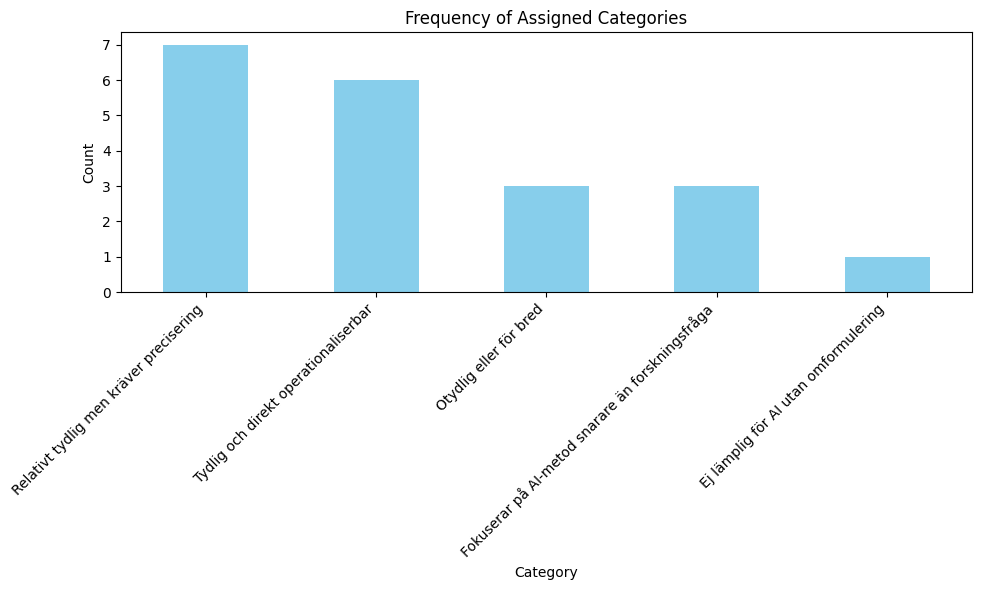

In [56]:
import json
import pandas as pd

# Parse the svar string into a Python list of dictionaries
data = json.loads(svar.replace('json', '', 1).strip())

# Extract the 'assigned Kategori' from each dictionary
kategorier = [entry['assigned Kategori'] for entry in data]

# Count the occurrences of each category and display frequencies
category_counts = pd.Series(kategorier).value_counts()
#print("Frequencies of 'assigned Kategori':")
#print(category_counts)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
category_counts.plot(kind='bar', color='skyblue')
plt.title('Frequency of Assigned Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Frågor Track A

Här har en LLM kodat era forskningsfrågor tillsammans med tillhörande datakällor.

1. Diskutera er egen fråga, datakälla, tilldelad kategori och motivering.
2. Hur kan ni anpassa detta exempel för att koda andra typer av texter med andra kategorier?
3. Hur kan ni säkerställa att kodningen är stabil, tillförlitlig och korrekt?




## TRACK B — CREATE ACTIONABLE (REGRESSION or CLASSIFICATION) MODELS


Denna del fokuserar på att bygga och utvärdera maskininlärningsmodeller för klassificering.
Den använder de tidigare kategoriserade forskningsfrågorna tillsammans med institutionsinformation för att träna en logistic regressionsmodell (som en approximation av klassificering) samt en beslutsträdsklassificerare.

Processen omfattar kodning av variabler, modellträning, prediktion samt utvärdering med hjälp av förväxlingsmatriser (confusion matrices) för att bedöma hur väl modellerna kan förutsäga de tilldelade kategorierna.

In [59]:
import pandas as pd
import json
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import numpy as np

# --- data (same as before) ---

departments_sv = [
    "kriminologi och polisiärt arbete",
    "idrottsvetenskap",
    "pedagogik",
    "pedagogik",
    "kriminologi och polisiärt arbete",
    "statsvetenskap",
    "pedagogik",
    "idrottsvetenskap",
    "statsvetenskap",
    "Samhällsstudier",
    "socialt arbete",
    "pedagogik",
    "statsvetenskap",
    "pedagogik",
    "pedagogik",
    "socialt arbete",
    "socialt arbete",
    "idrottsvetenskap",
    "socialt arbete",
    "rättsvetenskap"
]

kategorier = [entry["assigned Kategori"] for entry in data]

df = pd.DataFrame({
    "Institution": departments_sv,
    "Fördröjning": list(range(len(departments_sv))),
    "Kategori": kategorier
})

print(df)

# ==============================================
# 1. ENCODE FEATURES
# ==============================================

# One-hot encode Institution
encoder = OneHotEncoder(sparse_output=False)
X_cat = encoder.fit_transform(df[["Institution"]])

# Add Fördröjning as numeric feature
X = np.hstack([X_cat, df[["Fördröjning"]].values])

# Encode target labels
label_enc = LabelEncoder()
y = label_enc.fit_transform(df["Kategori"])

# ==============================================
# 2. LINEAR "CLASSIFICATION" (via regression)
# ==============================================

lr = LinearRegression()
lr.fit(X, y)

# Predict + round to nearest class
y_pred_lr = np.round(lr.predict(X)).astype(int)

# Clip to valid class range
y_pred_lr = np.clip(y_pred_lr, y.min(), y.max())

# 1. Initialize Logistic Regression
# 'multi_class' defaults to 'auto', which handles 5 categories perfectly.
# 'max_iter' is increased to ensure the solver converges on your TF-IDF data.
lr = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)

# 2. Fit the model
lr.fit(X, y)

# 3. Predict Classes
# Logistic Regression outputs the class index directly.
y_pred_lr = lr.predict(X)

# ==============================================
# 3. DECISION TREE CLASSIFIER (restricted depth)
# ==============================================

tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X, y)

y_pred_tree = tree.predict(X)


                         Institution  Fördröjning  \
0   kriminologi och polisiärt arbete            0   
1                   idrottsvetenskap            1   
2                          pedagogik            2   
3                          pedagogik            3   
4   kriminologi och polisiärt arbete            4   
5                     statsvetenskap            5   
6                          pedagogik            6   
7                   idrottsvetenskap            7   
8                     statsvetenskap            8   
9                    Samhällsstudier            9   
10                    socialt arbete           10   
11                         pedagogik           11   
12                    statsvetenskap           12   
13                         pedagogik           13   
14                         pedagogik           14   
15                    socialt arbete           15   
16                    socialt arbete           16   
17                  idrottsvetenskap          

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Confusion Matrix - Linear Regression (rounded):
[[0 0 0 1 0]
 [0 1 0 2 0]
 [0 0 2 0 1]
 [0 0 0 5 2]
 [0 0 0 1 5]]

Confusion Matrix - Decision Tree:
[[0 0 0 1 0]
 [0 0 0 3 0]
 [0 0 2 0 1]
 [0 0 0 5 2]
 [0 0 0 1 5]]


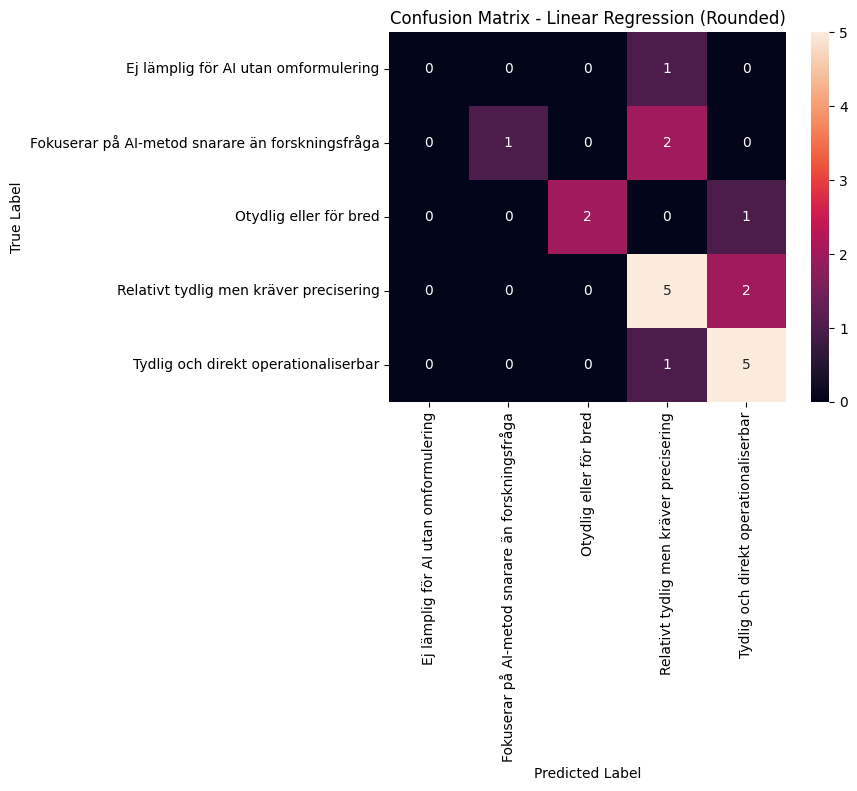

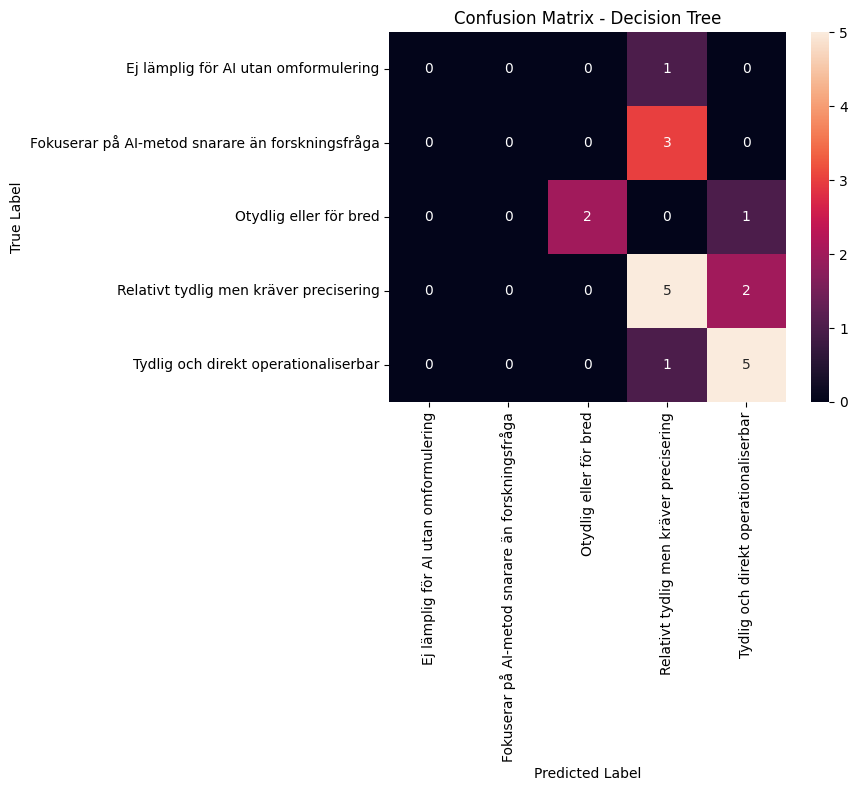

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================
# 4. CONFUSION MATRICES
# ==============================================

cm_lr = confusion_matrix(y, y_pred_lr)
cm_tree = confusion_matrix(y, y_pred_tree)

print("Confusion Matrix - Linear Regression (rounded):")
print(cm_lr)

print("\nConfusion Matrix - Decision Tree:")
print(cm_tree)

# Use class labels for axes
labels = label_enc.classes_

# ==============================================
# Linear Regression Confusion Matrix
# ==============================================
plt.figure()
sns.heatmap(cm_lr, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)

plt.title("Confusion Matrix - Linear Regression (Rounded)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

# ==============================================
# Decision Tree Confusion Matrix
# ==============================================
plt.figure()
sns.heatmap(cm_tree, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

## Frågor B

1. Hur presterar de två modellerna i förhållande till varandra?
2. Vilka problem uppstår om samma data används både för träning och testning av modellen?
3. Hur förväntas modellens klassifikationsförmåga förändras vid applicering på ny, osedd data?


## TRACK C — DATA ANALYSIS

Denna del genomför två typer av dataanalys.

För det första används en Random Forest-klassificerare för att bestämma variablernas betydelse (feature importance), det vill säga hur viktiga olika indata (såsom institutionstillhörighet och variabeln ”Fördröjning”) är för att förutsäga de tilldelade kategorierna.

För det andra genomförs en klusteranalys av texter (”Frågor och data” eller ”Motivering”).
Resultatet jämförs därefter visuellt med de faktiska grupperingarna (”Institutioner” eller ”LLM-kategorier”).

### Feature Importance

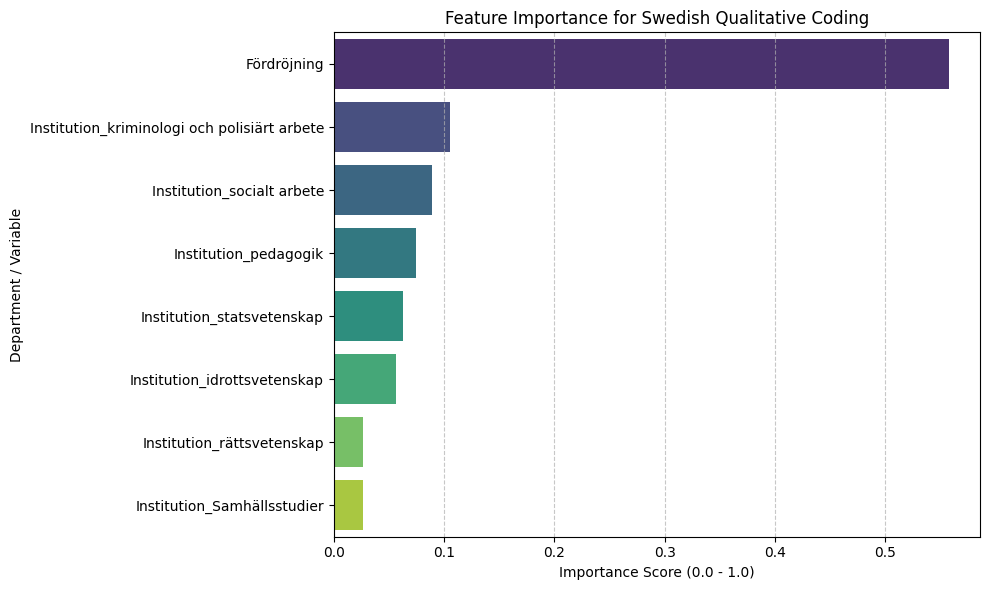


Top Predictors Summary:
                                        Feature  Importance
7                                   Fördröjning    0.557760
2  Institution_kriminologi och polisiärt arbete    0.105431
5                    Institution_socialt arbete    0.089487
3                         Institution_pedagogik    0.074986
6                    Institution_statsvetenskap    0.062413


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.ensemble import RandomForestClassifier

# 1. Data as before

# 2. Encode Features
encoder = OneHotEncoder(sparse_output=False)
X_cat = encoder.fit_transform(df[["Institution"]])

# Extract exact names: e.g., 'Institution_pedagogik'
feature_names = list(encoder.get_feature_names_out(['Institution']))
feature_names.append("Fördröjning") # Add the numeric feature name

# Combine features into one matrix
X = np.hstack([X_cat, df[["Fördröjning"]].values])
y = LabelEncoder().fit_transform(df["Kategori"])

# 3. Analyze Importance using Random Forest
# We use Forest because it reduces the "noise" of small datasets better than a single Tree.
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# 4. Create Importance DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 5. Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=importance_df, palette='viridis', legend=False)

plt.title('Feature Importance for Swedish Qualitative Coding')
plt.xlabel('Importance Score (0.0 - 1.0)')
plt.ylabel('Department / Variable')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nTop Predictors Summary:")
print(importance_df.head(5))

### Cluster analysis

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


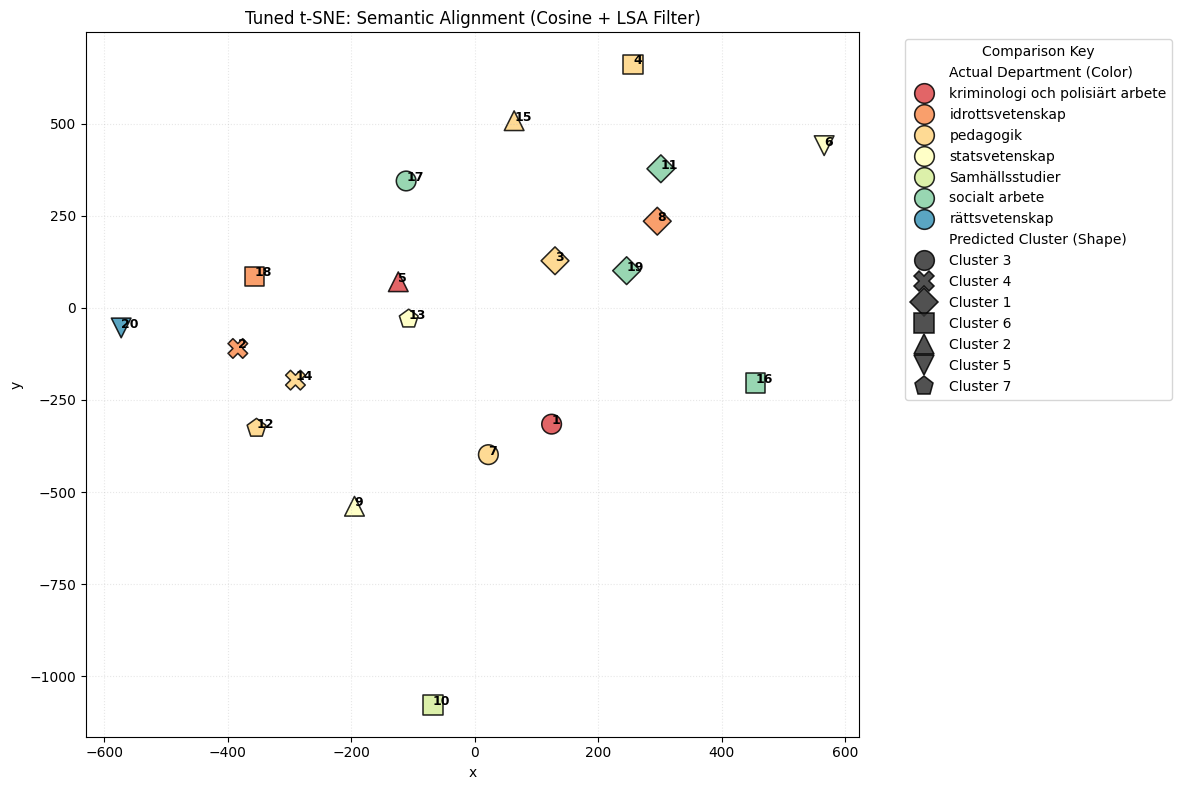

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.decomposition import TruncatedSVD # For LSA noise reduction
from sklearn.preprocessing import Normalizer

# 0. DATA: Select data
texts = texts_sv
# texts = [entry["Motivering"] for entry in data]

groups = departments_sv
# groups = [entry["assigned Kategori"] for entry in data]

# 1. SETUP
unique_cats = list(set(groups))
n_clusters = len(unique_cats)

# 2. VECTORIZATION
# Added ngram_range to catch phrases like "socialt arbete"
vectorizer = TfidfVectorizer(max_features=500, ngram_range=(1, 2))
X_tfidf = vectorizer.fit_transform(texts)

# 3. LSA STEP (Noise Reduction)
# Collapses high-dimensional noise into 10 'concept' dimensions
lsa = TruncatedSVD(n_components=10, random_state=42)
X_lsa = lsa.fit_transform(X_tfidf)
X_lsa = Normalizer(copy=False).fit_transform(X_lsa) # Re-normalize for clustering

# 4. KMEANS (Cluster on the cleaned LSA data)
kmeans = KMeans(n_clusters=n_clusters, random_state=42, max_iter=10)
kmeans_labels = kmeans.fit_predict(X_lsa)

# 5. TUNED t-SNE
# switched to metric='cosine' and init='pca' for better stability
tsne = TSNE(
    n_components=2,
    perplexity=3,          # Lowered for tight N=20 grouping
    metric='cosine',       # Crucial for text alignment
    init='pca',
    learning_rate='auto',
    n_iter=2000,           # More iterations for better convergence
    random_state=42
)
X_embedded = tsne.fit_transform(X_lsa)

# 6. PLOTTING
df_plot = pd.DataFrame({
    'x': X_embedded[:, 0],
    'y': X_embedded[:, 1],
    'Predicted Cluster (Shape)': [f'Cluster {l+1}' for l in kmeans_labels],
    'Actual Department (Color)': groups
})

plt.figure(figsize=(12, 8))
category_palette = 'Spectral'
cluster_markers = ['o', 'X', 'D', 's', '^', 'v', 'p', 'P', '*', 'h']

sns.scatterplot(
    data=df_plot,
    x='x', y='y',
    hue='Actual Department (Color)',
    style='Predicted Cluster (Shape)',
    palette=category_palette,
    markers=cluster_markers[:n_clusters],
    s=200,
    edgecolor='black', # Makes shapes pop
    alpha=0.85
)

# Use enumerate to safely map labels
for i, txt in enumerate(texts):
    plt.text(X_embedded[i, 0] + 0.05, X_embedded[i, 1] + 0.05, str(i+1), fontsize=9, weight='bold')

plt.legend(title='Comparison Key', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Tuned t-SNE: Semantic Alignment (Cosine + LSA Filter)')
plt.grid(True, linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()

## Frågor C

1. Vilken variable är mest avgörande för att klassificera rätt kategori?
2.